# Model Tester

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["XLA_FLAGS"] = (
    "--xla_gpu_cuda_data_dir=/hpc/mp/apps/nvidia/hpc_sdk/23.7/Linux_x86_64/23.7/cuda"
)

## Setup

In [3]:
import sys
import time
import logging

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import (
    EarlyStopping,
    TerminateOnNaN,
    TensorBoard,
    ModelCheckpoint,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, LearningRateSchedule
from tensorflow.keras.metrics import RootMeanSquaredError

sys.path.append(os.path.join(os.getcwd(), ".."))
from scripts.models import AutoModel
from scripts.models.modelcore import get_model_class
from scripts.utils import (
    setup_logging,
    load_data,
    get_fisher,
    plot_predictions,
    plot_histogram,
    print_errors,
)
from scripts.utils.tf import plot_metrics, TimedLoggingCallback, WarmupLearningRate

# tf.debugging.set_log_device_placement(True)

2024-07-29 12:40:58.252975: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-29 12:40:58.253047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-29 12:40:58.409715: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


29-Jul-24 12:41:43 - scripts.models.modelcore - DEBUG - Registering Model: ALM
29-Jul-24 12:41:43 - scripts.models.modelcore - DEBUG - Registering Model: ISENSEE
29-Jul-24 12:41:43 - scripts.models.modelcore - DEBUG - Registering Model: ISENSEE_V2
29-Jul-24 12:41:43 - scripts.models.modelcore - DEBUG - Registering Model: NAGARAJAPPA


In [4]:
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA version: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN version: {tf.sysconfig.get_build_info()['cudnn_version']}")

TensorFlow version: 2.15.0
CUDA version: 12.2
cuDNN version: 8


In [5]:
logger = setup_logging(__name__, base_level=logging.DEBUG)

In [6]:
from tensorflow.keras.backend import clear_session

# Function to reset the TensorFlow session and strategy
def reset_session_and_strategy():
    clear_session()  # Clear the current TensorFlow session
    strategy = tf.distribute.MirroredStrategy()  # Reinitialize the strategy
    return strategy

def plot_lr(lr, steps):
    # Compute learning rates for each step
    learning_rates = lr(steps)

    # Plot the learning rate as a function of steps
    plt.figure(figsize=(10, 6))
    plt.semilogy(steps, learning_rates)
    plt.xlabel('Steps')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True)
    plt.show()

## Configure

In [7]:
args = [
    "settings/n128.json",
    "--no-noise",
    "--nsims",
    "100",
    "--narray",
    "1000",
    # "--lensing",
    # "--pols",
]

MAX_EPOCHS = 10
BATCH_SIZE = 64

data_settings = {
    "shuffle": True,
    "shuffle_buffer": 1000,
    "seed": 0,
    "batch_size": BATCH_SIZE,
    "cache": True,
    "normalize": False,
    "channels_last": True,
}

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    # TensorBoard(log_dir=f"data/tensorboard/notebooks/{time.strftime('%Y%m%d-%H%M%S')}"),
    TerminateOnNaN(),
]

In [8]:
# from scripts.utils.tf import try_init_wandb
# try_init_wandb(notes="model testing", tags=["notebook"], append_to=callbacks)

## Isensee Model

In [9]:
# model = AutoModel(args + ["--model", "ISENSEE_V2"])

In [10]:
# train_ds, test_ds, val_ds = model.init_dataset(**data_settings).get_split(0.8, 0.1, 0.1)

In [11]:
# warmup_steps = len(train_ds) // BATCH_SIZE

# learning_rate = ExponentialDecay(1e-2, warmup_steps, 0.5, staircase=True)
# # learning_rate = WarmupLearningRate(warmup_steps=warmup_steps)

# plot_lr(learning_rate, np.arange(warmup_steps * MAX_EPOCHS))

# strategy = reset_session_and_strategy()
# with strategy.scope():
#     metrics = [RootMeanSquaredError()]
#     opt = Adam(learning_rate)
#     model.make_model()

#     # for layer in model._keras_model.layers:
#     #     if hasattr(layer, 'kernel_regularizer'):
#     #         layer.kernel_regularizer = l2(0.01)

#     model.compile(optimizer=opt, loss="mse", metrics=metrics)
#     model.summary()

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=MAX_EPOCHS,
#     callbacks=callbacks,
#     verbose=1,
# )

In [12]:
# fisher = get_fisher(model.file_complete)

# model.evaluate(test_ds, verbose=1)
# preds = model.predict(test_ds, verbose=1).flatten()
# truth = np.concatenate([y.numpy() for _, y in test_ds])

# plot_metrics(history, metrics=["loss"])
# plot_predictions(truth, preds, fisher=fisher)
# plot_histogram(truth, preds)
# print_errors(truth, preds, fisher)

## ALM Model

29-Jul-24 12:41:44 - scripts.core - INFO - Loading settings from file settings/n128.json
29-Jul-24 12:41:44 - scripts.core - INFO - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.9649,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 100,
  "narray": 1000,
  "nside": 128,
  "noise": false
}
29-Jul-24 12:41:47 - scripts.utils.tf.dataloaders - INFO - Loading data/data/n128_ul-nn_Tx100000.hdf5 with 100000 samples, and data shape (383, 383, 2)


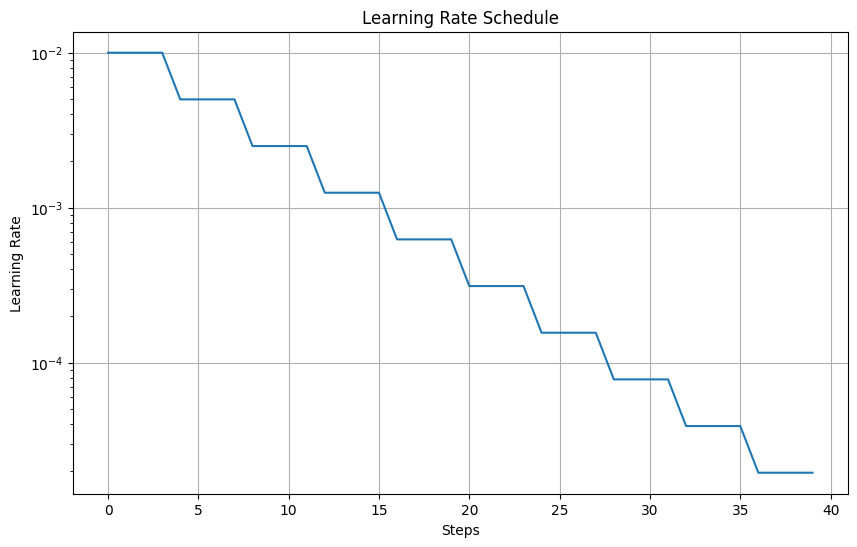

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
29-Jul-24 12:41:54 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
Model: "n128_ul-nn_Tx100000"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 383, 383, 2)]        0         []                            
                                                                                                  
 tf.reshape (TFOpLambda)     (None, 383, 766)             0 

I0000 00:00:1722274951.700955  857610 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


312/312 [==============================] - ETA: 0s - loss: 350.5203 - root_mean_squared_error: 18.7222INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
29-Jul-24 12:44:40 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
29-Jul-24 12:44:40 - tensorflow - INFO - Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
312/312 [==============================] - 276s 760ms/step - loss: 350.5203 - root_mean_squared_error: 18.7222 - val_loss: 152.6235 - val_root_mean_squared_error: 12.3541
Epoch 2/10
312/312 [==============================] - 25s 78ms/step - loss: 153.6475 - root_mean_squared_error: 12.39

In [13]:
model = get_model_class("ALM")(args)
train_ds, test_ds, val_ds = model.init_dataset(**data_settings).get_split(0.8, 0.1, 0.1)

warmup_steps = len(train_ds) // BATCH_SIZE
learning_rate = ExponentialDecay(1e-2, warmup_steps, 0.5, staircase=True)
# learning_rate = WarmupLearningRate(warmup_steps=warmup_steps)

plot_lr(learning_rate, np.arange(warmup_steps * MAX_EPOCHS))

strategy = reset_session_and_strategy()
with strategy.scope():
    metrics = [RootMeanSquaredError()]
    opt = Adam(learning_rate)
    model.make_model()
    model.compile(optimizer=opt, loss="mse", metrics=metrics)
    model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

29-Jul-24 12:50:09 - scripts.utils.utils - INFO - Loaded fisher matrix: 0.0023901845129936797
39/39 [==============================] - 6s 44ms/step


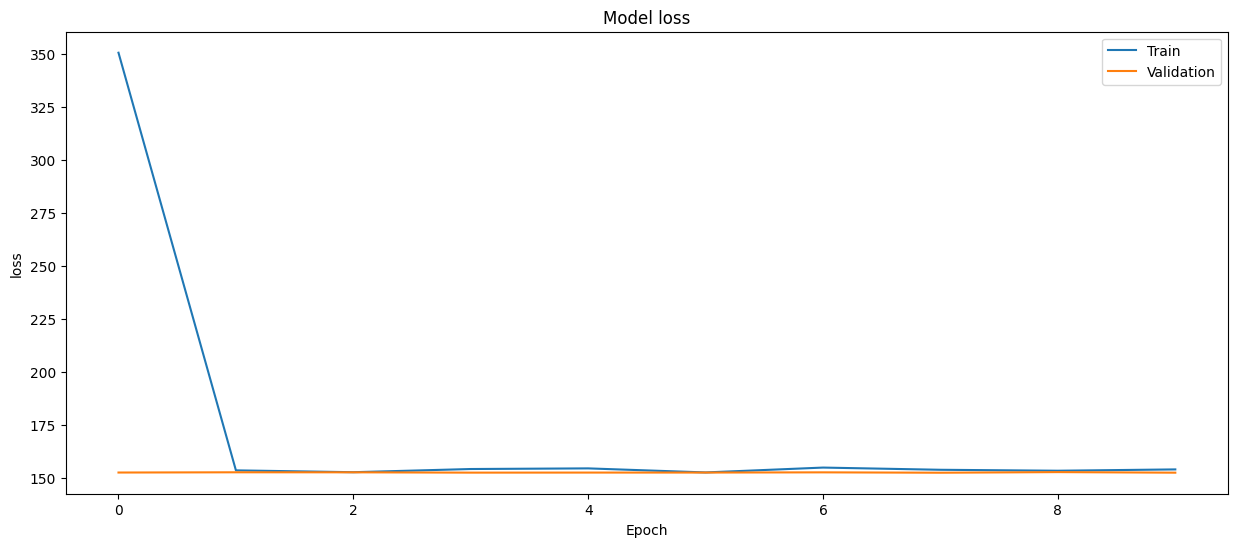

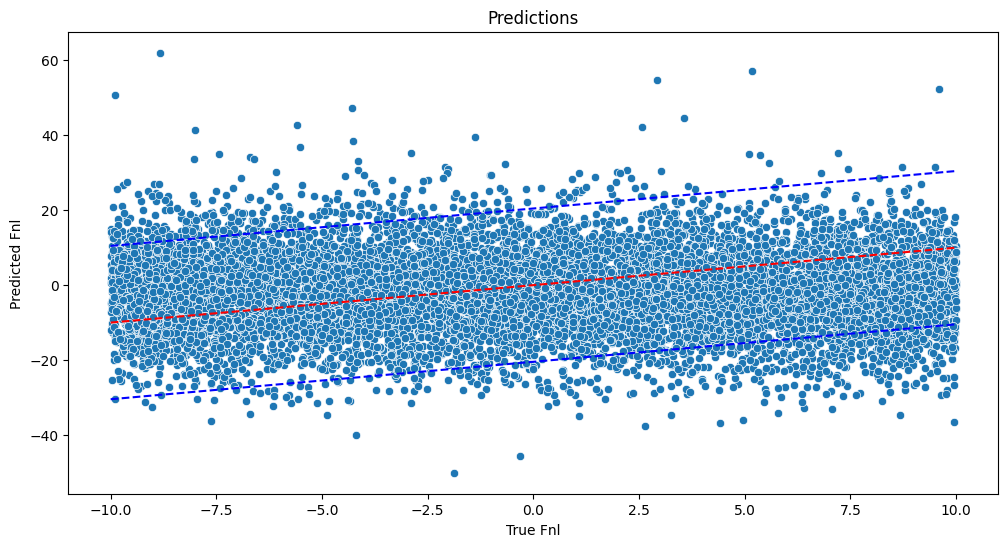

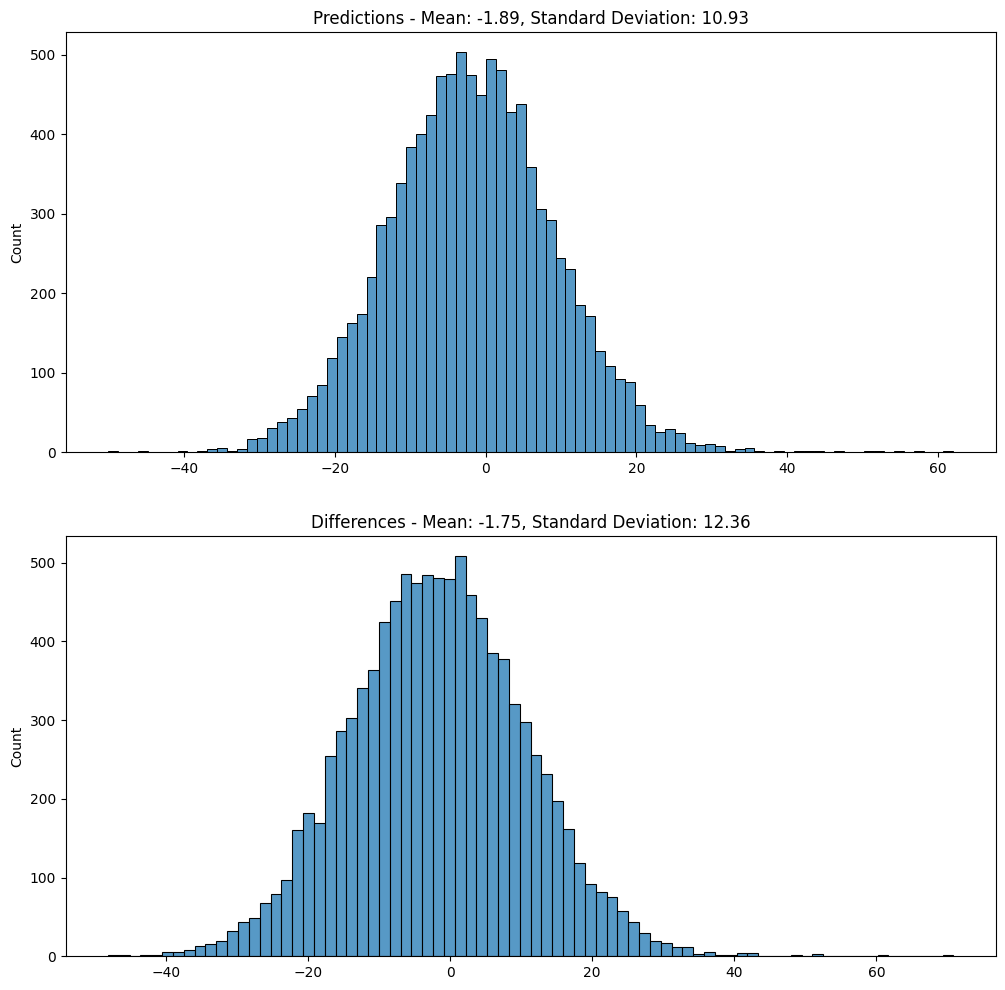

29-Jul-24 12:52:00 - scripts.utils.utils - INFO - Standard deviation: 20.45428420173009, SEM: 0.20470667291422498
29-Jul-24 12:52:00 - scripts.utils.utils - INFO - 89.90384615384616% (89.55328525641025, 90.25440705128204) are within 1 standard deviations
29-Jul-24 12:52:00 - scripts.utils.utils - INFO - 99.79967948717949% (99.78966346153845, 99.83974358974359) are within 2 standard deviations
29-Jul-24 12:52:00 - scripts.utils.utils - INFO - 99.98998397435898% (99.98998397435898, 99.98998397435898) are within 3 standard deviations
29-Jul-24 12:52:00 - scripts.utils.utils - INFO - 100.0% (100.0, 100.0) are within 4 standard deviations
29-Jul-24 12:52:00 - scripts.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


In [14]:
fisher = get_fisher(model.file_complete)

model.evaluate(test_ds, verbose=1)
preds = model.predict(test_ds, verbose=1).flatten()
truth = np.concatenate([y.numpy() for _, y in test_ds]).flatten()

plot_metrics(history, metrics=["loss"])
plot_predictions(truth, preds, fisher=fisher)
plot_histogram(truth, preds)
print_errors(truth, preds, fisher)

## NAGARAJAPPA

29-Jul-24 12:52:00 - scripts.core - INFO - Loading settings from file settings/n128.json
29-Jul-24 12:52:00 - scripts.core - INFO - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.9649,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 100,
  "narray": 1000,
  "nside": 128,
  "noise": false
}
29-Jul-24 12:52:03 - scripts.utils.tf.dataloaders - INFO - Loading data/data/n128_ul-nn_Tx100000.hdf5 with 100000 samples, data shape (128, 128, 10), with std div 20.45428420173009


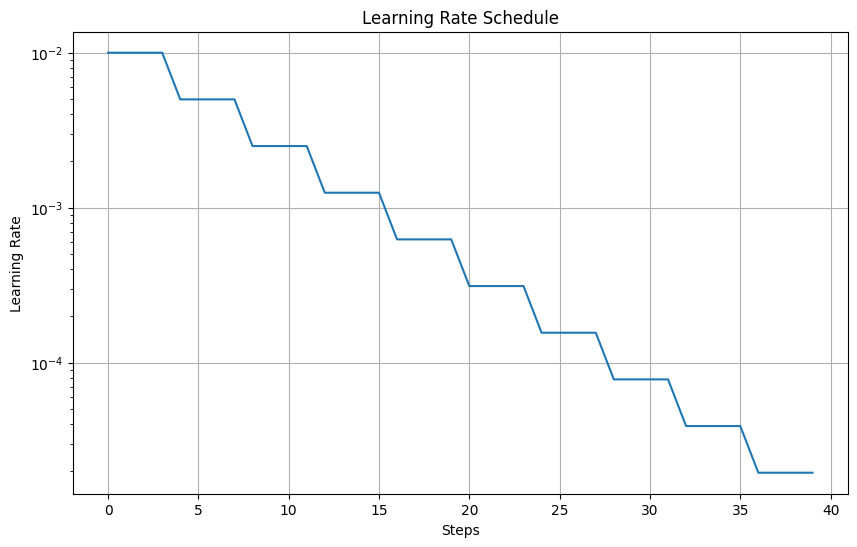

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
29-Jul-24 12:52:06 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1', '/job:localhost/replica:0/task:0/device:GPU:2', '/job:localhost/replica:0/task:0/device:GPU:3')
Model: "n128_ul-nn_Tx100000"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 10)]    0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 32)      2912      
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0    

2024-07-29 12:52:29.136709: E tensorflow/core/common_runtime/base_collective_executor.cc:249] BaseCollectiveExecutor::StartAbort INVALID_ARGUMENT: Shape mismatch in the collective instance 100. Op at device /job:localhost/replica:0/task:0/device:GPU:1 expected shape [14808481] but another member in the group expected shape [10552554]. This is likely due to different input shapes at different members of the collective op.


InvalidArgumentError: Graph execution error:

Detected at node CollectiveReduceV2_2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/asyncio/base_events.py", line 607, in run_forever

  File "/work/users/stevensonb/.conda/envs/mlpng-gpu/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

  

In [15]:
model = get_model_class("NAGARAJAPPA")(args)
train_ds, test_ds, val_ds = model.init_dataset(**data_settings).get_split(0.8, 0.1, 0.1)

warmup_steps = len(train_ds) // BATCH_SIZE
learning_rate = ExponentialDecay(1e-2, warmup_steps, 0.5, staircase=True)

plot_lr(learning_rate, np.arange(warmup_steps * MAX_EPOCHS))

strategy = reset_session_and_strategy()
with strategy.scope():
    metrics = [RootMeanSquaredError()]
    opt = Adam(learning_rate)
    model.make_model()
    model.compile(optimizer=opt, loss="mse", metrics=metrics)
    model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=0,
)

In [ ]:
fisher = get_fisher(model.file_complete)

model.evaluate(test_ds, verbose=1)
preds = model.predict(test_ds, verbose=1).flatten()
truth = np.concatenate([y.numpy() for _, y in test_ds])

plot_metrics(history, metrics=["loss"])
plot_predictions(truth, preds, fisher=fisher)
plot_histogram(truth, preds)
print_errors(truth, preds, fisher)